# GI Stage 2 — Data Processing Notebook (v2)
### GDSC2/CCLE realigned to GIBridge-MLP's gene space - Warm-start + Cell-cold splits

**What changed vs v1:** the core logic is unchanged and already validated against a real run
(79 cell lines, 1,579 pairs, correct lineage breakdown, correct scaler statistics). This
version adds:
1. More verbose logging (timing, memory at every step)
2. More figures (IC50 distribution by lineage, drug x lineage coverage heatmap, cell-cold
   split composition)
3. Morgan fingerprints computed fresh from SMILES as the standard method (not a bolted-on
   fix -- this is what actually worked when the precomputed fingerprint files turned out to
   be missing from the dataset)
4. A new early check: **each omics modality tested alone against per-cell-line mean IC50**,
   before any Stage 2 fusion model is built -- the same "test modalities alone first" lesson
   applied to classification in Stage 1, adapted here for regression.

**Correction carried over from v1:** CCLE scalers are fit fresh on GI CCLE training cell
lines, not reused from GIBridge Stage 1's TCGA-fitted scalers -- cell lines and tissue
samples have systematically different baseline expression distributions. Only the **selected
gene names** transfer from Stage 1, not the scaler objects.

**Dropped cell lines:** Biliary Tract (1 cell line); Small Bowel folds into the Bowel
lineage rather than standing alone.

**Inputs needed:**
1. GIBridge Stage 1 v2's saved gene-name JSONs
2. `drug-cell-line-data-phase-2` -- raw CCLE omics CSVs + Model.csv
3. Your GDSC2 splits dataset -- for the pre-merged IC50 table and `drug_smiles.json`


> **v3 note:** only two cells changed from your existing data-processing notebook -- `CFG['GENE_JSON_DIR']` (Cell 2) now points at the Stage 1 v3 output directory, and the gene-JSON filename pattern (Cell 3) is `gibridge_genes_{mod}.json` instead of `gibridge_selected_genes_{mod}.json`, matching Stage 1 v3's actual saved filenames (500/300/300/500 genes instead of the old 4000/1750/1250/3000). Every other cell -- raw CCLE loading, preprocessing, splits, Morgan fingerprints, output saves -- is unchanged.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, gc, warnings
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, KFold, cross_val_predict
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '=' * 70)
    print(f'  {title}')
    print('=' * 70)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM usage: {mb:.1f} MB | shape: {df.shape}')

def timed(label):
    class _T:
        def __enter__(self):
            self.t0 = time.time()
            return self
        def __exit__(self, *a):
            print(f'  [{label}] done in {time.time()-self.t0:.1f}s')
    return _T()

print('Setup complete.')


Setup complete.


In [2]:
section('CONFIG')

CFG = dict(
    SEED = 42,
    WARM_VAL_FRAC   = 0.10,
    WARM_TEST_FRAC  = 0.10,
    CELL_COLD_FRAC  = 0.20,   # review per-lineage counts printed below before finalising

    GI_LINEAGES_KEEP = ['Bowel', 'Esophagus/Stomach', 'Pancreas', 'Liver'],

    GENE_JSON_DIR = '/kaggle/input/datasets/proutkarshtiwari/gi-outputeee-stage-1',  # UPDATE -- Stage 1 v3 output dir
    RAW_CCLE_BASE = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2',
    GDSC2_BASE    = '/kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2',      # UPDATE if needed
    MODEL_CSV     = 'Model.csv',
    MRNA_CSV      = 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv',
    CNV_CSV       = 'OmicsCNGeneWGS.csv',
    MUT_CSV       = 'OmicsSomaticMutationsMatrixDamaging.csv',
    METH_CSV      = 'CCLE_RRBS_TSS_1kb_20180614.txt',
    OUT_DIR       = '/kaggle/working/',
)

print('CFG loaded.')
print(f'GI lineages kept: {CFG["GI_LINEAGES_KEEP"]}')
print(f'Cell-cold fraction: {CFG["CELL_COLD_FRAC"]*100:.0f}%')



  CONFIG
CFG loaded.
GI lineages kept: ['Bowel', 'Esophagus/Stomach', 'Pancreas', 'Liver']
Cell-cold fraction: 20%


In [3]:
section('GIBridge Stage 1 v3 selected gene names')

GENES_GI = {}
for mod in ['mrna', 'cnv', 'mut', 'meth']:
    path = f"{CFG['GENE_JSON_DIR']}/gibridge_genes_{mod}.json"
    with open(path) as f:
        GENES_GI[mod] = json.load(f)

print('Gene counts (must match GIBridge Stage 1 v3 CONFIG exactly):')
for k, v in GENES_GI.items():
    print(f'  {k:>4}: {len(v):>6,} genes')
print(f'  Total features: {sum(len(v) for v in GENES_GI.values()):,}')



  GIBridge Stage 1 v3 selected gene names
Gene counts (must match GIBridge Stage 1 v3 CONFIG exactly):
  mrna:  2,000 genes
   cnv:    300 genes
   mut:    300 genes
  meth:  2,000 genes
  Total features: 4,600


In [4]:
section('IC50 pairs -- load full cohort and filter to GI lineages')

with timed('load + concat 3 warm-split parquets'):
    warm_tr = pd.read_parquet(f"{CFG['GDSC2_BASE']}/split_warm_tr.parquet")
    warm_vl = pd.read_parquet(f"{CFG['GDSC2_BASE']}/split_warm_vl.parquet")
    warm_te = pd.read_parquet(f"{CFG['GDSC2_BASE']}/split_warm_te.parquet")
    ic50_all = pd.concat([warm_tr, warm_vl, warm_te], ignore_index=True)
    del warm_tr, warm_vl, warm_te

print(f'Full cohort: {len(ic50_all):,} pairs | {ic50_all["ModelID"].nunique()} cell lines | '
      f'{ic50_all["DRUG_NAME"].nunique()} drugs')

ic50 = ic50_all[ic50_all['OncotreeLineage'].isin(CFG['GI_LINEAGES_KEEP'])].copy()
del ic50_all

print(f'\nAfter GI-lineage filter: {len(ic50):,} pairs | '
      f'{ic50["ModelID"].nunique()} cell lines | {ic50["DRUG_NAME"].nunique()} drugs')
print('\nCell lines per lineage:')
print(ic50.drop_duplicates('ModelID')['OncotreeLineage'].value_counts().to_string())

print('\nNo per-drug minimum re-applied -- clinically standard GI drugs (5-FU, oxaliplatin)')
print('have too few pairs to survive a strict filter. Every drug the model sees is real')
print('GDSC2 data; sample-size honesty happens at evaluation time, not by filtering here.')

valid_model_ids = set(ic50['ModelID'].unique())
print(f'\nvalid_model_ids: {len(valid_model_ids)} GI cell lines')



  IC50 pairs -- load full cohort and filter to GI lineages
  [load + concat 3 warm-split parquets] done in 0.3s
Full cohort: 9,967 pairs | 388 cell lines | 74 drugs

After GI-lineage filter: 1,579 pairs | 79 cell lines | 71 drugs

Cell lines per lineage:
OncotreeLineage
Esophagus/Stomach    30
Bowel                24
Pancreas             14
Liver                11

No per-drug minimum re-applied -- clinically standard GI drugs (5-FU, oxaliplatin)
have too few pairs to survive a strict filter. Every drug the model sees is real
GDSC2 data; sample-size honesty happens at evaluation time, not by filtering here.

valid_model_ids: 79 GI cell lines


In [5]:
section('CCLE mRNA -- reindexed to GIBridge gene space')

mrna_raw = pd.read_csv(f"{CFG['RAW_CCLE_BASE']}/{CFG['MRNA_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in mrna_raw.columns:
    mrna_raw = mrna_raw[mrna_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mrna_raw = mrna_raw.set_index('ModelID')
    mrna_raw = mrna_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                       'IsDefaultEntryForMC', 'IsDefaultEntryForModel'], errors='ignore')

mrna_raw.columns = [str(c).split(' (')[0].strip() for c in mrna_raw.columns]
mrna_raw = mrna_raw.loc[:, ~mrna_raw.columns.duplicated(keep='first')]
mrna_raw = mrna_raw[mrna_raw.index.isin(valid_model_ids)]

overlap_m = set(mrna_raw.columns) & set(GENES_GI['mrna'])
print(f'mRNA overlap with GIBridge genes: {len(overlap_m)}/{len(GENES_GI["mrna"])}')

mrna_df = mrna_raw.reindex(columns=GENES_GI['mrna'], fill_value=0.0).fillna(0.0).astype(np.float32)
print(f'Final mRNA: {mrna_df.shape}')
valid_model_ids_mrna = set(mrna_df.index)
del mrna_raw; gc.collect()
mem_usage(mrna_df, 'mRNA')



  CCLE mRNA -- reindexed to GIBridge gene space
mRNA overlap with GIBridge genes: 1891/2000
Final mRNA: (79, 2000)
  [mRNA] RAM usage: 0.6 MB | shape: (79, 2000)


In [6]:
section('CCLE CNV -- reindexed to GIBridge gene space')

cnv_raw = pd.read_csv(f"{CFG['RAW_CCLE_BASE']}/{CFG['CNV_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in cnv_raw.columns:
    cnv_raw = cnv_raw[cnv_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    cnv_raw = cnv_raw.set_index('ModelID')
    cnv_raw = cnv_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                     'IsDefaultEntryForMC', 'IsDefaultEntryForModel'], errors='ignore')

cnv_raw.columns = [str(c).split(' (')[0].strip() for c in cnv_raw.columns]
cnv_raw = cnv_raw.loc[:, ~cnv_raw.columns.duplicated(keep='first')]
cnv_raw = cnv_raw[cnv_raw.index.isin(valid_model_ids)]
cnv_raw = cnv_raw.fillna(2.0).clip(lower=0.01)
cnv_raw = np.log2(cnv_raw / 2.0).astype(np.float32)

overlap_c = set(cnv_raw.columns) & set(GENES_GI['cnv'])
print(f'CNV overlap with GIBridge genes: {len(overlap_c)}/{len(GENES_GI["cnv"])}')

cnv_df = cnv_raw.reindex(columns=GENES_GI['cnv'], fill_value=0.0).astype(np.float32)
print(f'Final CNV: {cnv_df.shape}')
valid_model_ids_cnv = set(cnv_df.index)
del cnv_raw; gc.collect()
mem_usage(cnv_df, 'CNV')



  CCLE CNV -- reindexed to GIBridge gene space
CNV overlap with GIBridge genes: 280/300
Final CNV: (79, 300)
  [CNV] RAM usage: 0.1 MB | shape: (79, 300)


In [7]:
section('CCLE Mutation -- reindexed to GIBridge gene space')

mut_raw = pd.read_csv(f"{CFG['RAW_CCLE_BASE']}/{CFG['MUT_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in mut_raw.columns:
    mut_raw = mut_raw[mut_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mut_raw = mut_raw.set_index('ModelID')
    mut_raw = mut_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                     'IsDefaultEntryForMC', 'IsDefaultEntryForModel'], errors='ignore')

mut_raw.columns = [str(c).split(' (')[0].strip() for c in mut_raw.columns]
mut_raw = mut_raw.loc[:, ~mut_raw.columns.duplicated(keep='first')]
mut_raw = mut_raw[mut_raw.index.isin(valid_model_ids)]
mut_raw = mut_raw.fillna(0).clip(0, 1).round(0).astype(np.int8)

overlap_u = set(mut_raw.columns) & set(GENES_GI['mut'])
sparsity  = (mut_raw == 0).values.mean()
print(f'Mutation overlap with GIBridge genes: {len(overlap_u)}/{len(GENES_GI["mut"])}')
print(f'Sparsity (wildtype fraction): {sparsity*100:.1f}%')

mut_df = mut_raw.reindex(columns=GENES_GI['mut'], fill_value=0).astype(np.float32)
print(f'Final Mutation: {mut_df.shape}')
valid_model_ids_mut = set(mut_df.index)
del mut_raw; gc.collect()
mem_usage(mut_df, 'Mutation')



  CCLE Mutation -- reindexed to GIBridge gene space
Mutation overlap with GIBridge genes: 286/300
Sparsity (wildtype fraction): 99.3%
Final Mutation: (79, 300)
  [Mutation] RAM usage: 0.1 MB | shape: (79, 300)


In [8]:
section('CCLE Methylation (RRBS) -- reindexed to GIBridge gene space')

print('Loading CCLE_RRBS_TSS_1kb_20180614.txt...')
meth_raw = pd.read_csv(f"{CFG['RAW_CCLE_BASE']}/{CFG['METH_CSV']}", sep='\t', low_memory=False)
print(f'Raw shape: {meth_raw.shape}')

gene_col_values = meth_raw['gene'].values if 'gene' in meth_raw.columns else meth_raw.iloc[:, 0].values
meta_cols = ['gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage']
meth_data = meth_raw.drop(columns=meta_cols, errors='ignore')
meth_data = meth_data.apply(pd.to_numeric, errors='coerce').astype(np.float32)
meth_data.index = gene_col_values

n_tss_before = len(meth_data)
meth_data = meth_data.groupby(meth_data.index).mean()
print(f'TSS aggregation: {n_tss_before:,} TSS -> {len(meth_data):,} unique genes')
meth_data = meth_data.T

model_map = pd.read_csv(f"{CFG['RAW_CCLE_BASE']}/{CFG['MODEL_CSV']}", usecols=['ModelID', 'CCLEName'])
model_map = model_map.dropna(subset=['CCLEName'])
ccle_to_model = dict(zip(model_map['CCLEName'], model_map['ModelID']))

meth_data.index = meth_data.index.map(lambda x: ccle_to_model.get(x, None))
meth_data = meth_data[meth_data.index.notna()].copy()
meth_data.index = meth_data.index.astype(str)
meth_data = meth_data[meth_data.index.isin(valid_model_ids)].copy()
print(f'Filtered to GI cell lines: {len(meth_data)}')

gene_means_fill = meth_data.mean(axis=0)
meth_data = meth_data.fillna(gene_means_fill).fillna(0.5).clip(0.0, 1.0).astype(np.float32)

overlap_e = set(meth_data.columns) & set(GENES_GI['meth'])
print(f'Methylation overlap with GIBridge genes: {len(overlap_e)}/{len(GENES_GI["meth"])}')

meth_df = meth_data.reindex(columns=GENES_GI['meth'], fill_value=0.5).astype(np.float32)
print(f'Final Methylation: {meth_df.shape}')

valid_model_ids_meth = set(meth_df.index)
del meth_raw, meth_data, model_map, ccle_to_model
gc.collect()
mem_usage(meth_df, 'Methylation')



  CCLE Methylation (RRBS) -- reindexed to GIBridge gene space
Loading CCLE_RRBS_TSS_1kb_20180614.txt...
Raw shape: (20192, 850)
TSS aggregation: 20,192 TSS -> 16,494 unique genes
Filtered to GI cell lines: 67
Methylation overlap with GIBridge genes: 1364/2000
Final Methylation: (67, 2000)
  [Methylation] RAM usage: 0.5 MB | shape: (67, 2000)


In [9]:
section('Master alignment (GI subset)')

print('Cell lines per modality:')
print(f'  mRNA : {len(valid_model_ids_mrna):,}')
print(f'  CNV  : {len(valid_model_ids_cnv):,}')
print(f'  Mut  : {len(valid_model_ids_mut):,}')
print(f'  Meth : {len(valid_model_ids_meth):,}')

have_3 = valid_model_ids_mrna & valid_model_ids_cnv & valid_model_ids_mut
have_all4 = have_3 & valid_model_ids_meth
have_3_no_meth = have_3 - valid_model_ids_meth

print(f'\nAll 4 modalities: {len(have_all4):,}')
print(f'mRNA+CNV+Mut only: {len(have_3_no_meth):,} (methylation imputed with 0.5)')

if len(have_3_no_meth) > 0:
    imp_meth = pd.DataFrame(0.5, index=sorted(have_3_no_meth), columns=GENES_GI['meth'], dtype=np.float32)
    meth_df = pd.concat([meth_df, imp_meth])

common_final = sorted(have_all4 | have_3_no_meth)
print(f'\nFinal usable GI cell lines: {len(common_final)}')

mrna_df = mrna_df.loc[mrna_df.index.isin(common_final)].reindex(common_final)
cnv_df  = cnv_df.loc[cnv_df.index.isin(common_final)].reindex(common_final)
mut_df  = mut_df.loc[mut_df.index.isin(common_final)].reindex(common_final)
meth_df = meth_df.loc[meth_df.index.isin(common_final)].reindex(common_final)

assert (mrna_df.index == cnv_df.index).all()
assert (mrna_df.index == mut_df.index).all()
assert (mrna_df.index == meth_df.index).all()
print('All modalities aligned OK')

ic50 = ic50[ic50['ModelID'].isin(common_final)].copy()
print(f'IC50 pairs after alignment: {len(ic50):,}')
print('\nCell lines per lineage (final, post-alignment):')
print(ic50.drop_duplicates('ModelID')['OncotreeLineage'].value_counts().to_string())



  Master alignment (GI subset)
Cell lines per modality:
  mRNA : 79
  CNV  : 79
  Mut  : 79
  Meth : 67

All 4 modalities: 67
mRNA+CNV+Mut only: 12 (methylation imputed with 0.5)

Final usable GI cell lines: 79
All modalities aligned OK
IC50 pairs after alignment: 1,579

Cell lines per lineage (final, post-alignment):
OncotreeLineage
Esophagus/Stomach    30
Bowel                24
Pancreas             14
Liver                11



  NEW: each modality tested alone against per-cell-line mean IC50
Same lesson as Stage 1, adapted for regression: know upfront how much signal each
omics modality carries about drug sensitivity, before investing in Stage 2 fusion.

  [mRNA        ] Pearson (5-fold CV, out-of-fold, top 500 var genes): 0.496
  [CNV         ] Pearson (5-fold CV, out-of-fold, top 500 var genes): -0.052
  [Mutation    ] Pearson (5-fold CV, out-of-fold, top 500 var genes): 0.105
  [Methylation ] Pearson (5-fold CV, out-of-fold, top 500 var genes): 0.331


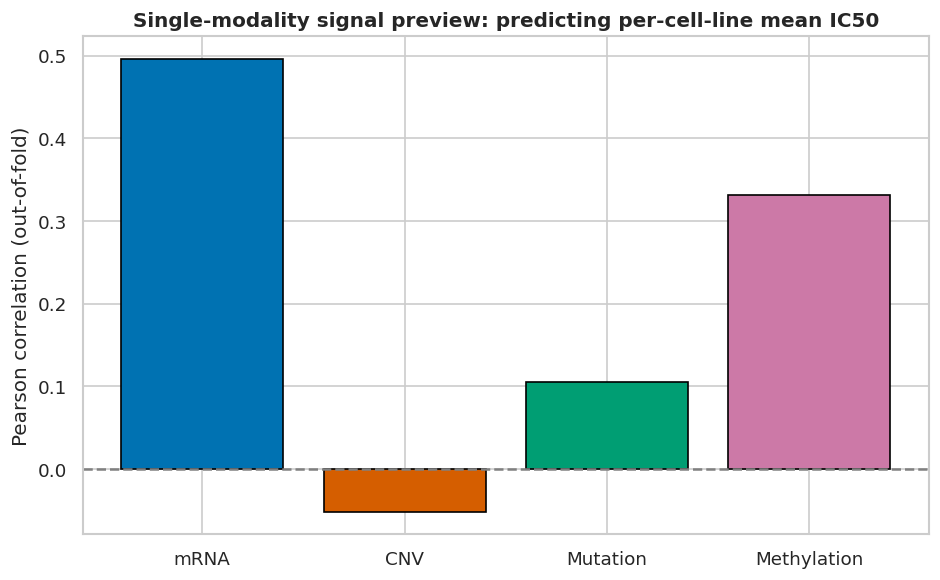


This is a coarse preview (per-cell-line MEAN IC50, not per-drug) -- it tells you
whether a modality carries any drug-sensitivity signal at all, not the final model.


In [10]:
section('NEW: each modality tested alone against per-cell-line mean IC50')
print('Same lesson as Stage 1, adapted for regression: know upfront how much signal each')
print('omics modality carries about drug sensitivity, before investing in Stage 2 fusion.\n')

cl_mean_ic50 = ic50.groupby('ModelID')['ic50_value'].mean()
target = cl_mean_ic50.reindex(common_final).values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
modality_regression_results = {}

for name, df in [('mRNA', mrna_df), ('CNV', cnv_df), ('Mutation', mut_df), ('Methylation', meth_df)]:
    var_top = df.var(axis=0).sort_values(ascending=False).head(500).index
    Xr = df[var_top].fillna(df[var_top].mean()).values
    Xr_scaled = StandardScaler().fit_transform(Xr)
    ridge = Ridge(alpha=10.0)
    preds_cv = cross_val_predict(ridge, Xr_scaled, target, cv=kf)
    r, _ = pearsonr(preds_cv, target)
    modality_regression_results[name] = r
    print(f'  [{name:12s}] Pearson (5-fold CV, out-of-fold, top 500 var genes): {r:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
names_r = list(modality_regression_results.keys())
vals_r = [modality_regression_results[n] for n in names_r]
colors_r = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
ax.bar(names_r, vals_r, color=colors_r, edgecolor='black')
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Pearson correlation (out-of-fold)')
ax.set_title('Single-modality signal preview: predicting per-cell-line mean IC50', fontweight='bold')
plt.tight_layout()
plt.savefig('gi_stage2_single_modality_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThis is a coarse preview (per-cell-line MEAN IC50, not per-drug) -- it tells you')
print('whether a modality carries any drug-sensitivity signal at all, not the final model.')



  Generating splits: warm-start + cell-cold (no drug-cold)
------------------------------------------------------------
SPLIT 1: WARM-START (80/10/10 random pair split)
------------------------------------------------------------
  Train pairs: 1,263 | Val:   158 | Test:   158

------------------------------------------------------------
SPLIT 2: CELL-COLD-START (20% cell lines held out)
------------------------------------------------------------
  Train cell lines:  53 | pairs: 1,111
  Val   cell lines:  10 | pairs:   170
  Test  cell lines:  16 | pairs:   298 (unseen)
  Leakage assertions passed

Cell-cold split composition per lineage:
                   train  val  test
Esophagus/Stomach     20    4     6
Bowel                 16    3     5
Pancreas               9    2     3
Liver                  8    1     2


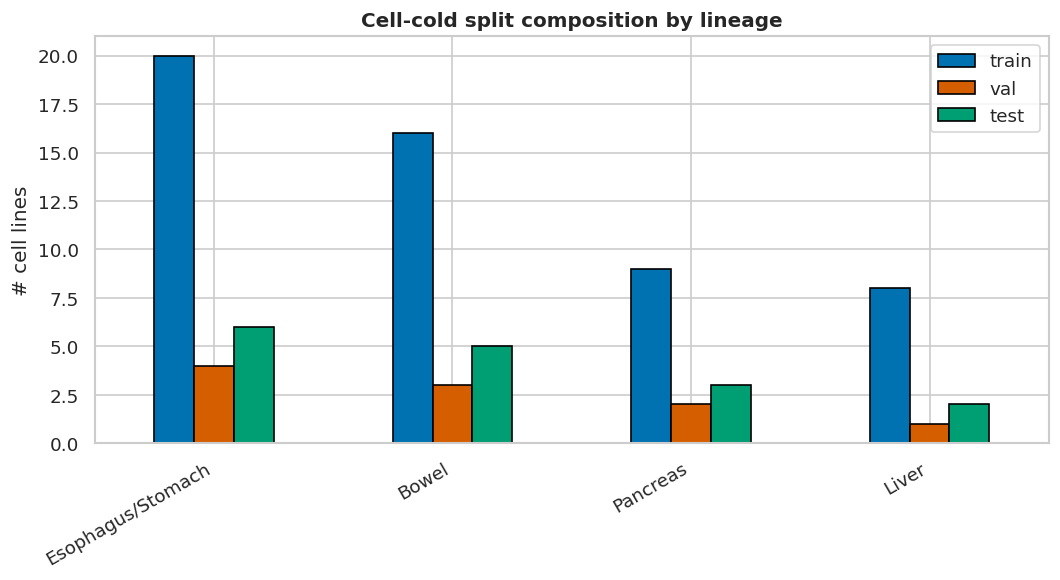

In [11]:
section('Generating splits: warm-start + cell-cold (no drug-cold)')

np.random.seed(CFG['SEED'])
all_cls_arr = np.array(common_final)
cl_lineage_map = ic50.drop_duplicates('ModelID').set_index('ModelID')['OncotreeLineage'].to_dict()
lineage_arr = np.array([cl_lineage_map.get(cl, 'Unknown') for cl in all_cls_arr])

def safe_stratify_encode(labels_arr):
    s = pd.Series(labels_arr)
    counts = s.value_counts()
    dominant = counts.index[0]
    safe = np.where(s.map(counts) < 4, dominant, labels_arr)
    return LabelEncoder().fit_transform(safe)

lineage_enc = safe_stratify_encode(lineage_arr)

print('-' * 60); print('SPLIT 1: WARM-START (80/10/10 random pair split)'); print('-' * 60)
tv_pairs, ic50_warm_te = train_test_split(ic50, test_size=CFG['WARM_TEST_FRAC'], random_state=CFG['SEED'])
ic50_warm_tr, ic50_warm_vl = train_test_split(
    tv_pairs, test_size=CFG['WARM_VAL_FRAC'] / (1.0 - CFG['WARM_TEST_FRAC']), random_state=CFG['SEED'])
print(f'  Train pairs: {len(ic50_warm_tr):>5,} | Val: {len(ic50_warm_vl):>5,} | Test: {len(ic50_warm_te):>5,}')

print('\n' + '-' * 60)
print(f'SPLIT 2: CELL-COLD-START ({CFG["CELL_COLD_FRAC"]*100:.0f}% cell lines held out)')
print('-' * 60)
sss_outer = StratifiedShuffleSplit(n_splits=1, test_size=CFG['CELL_COLD_FRAC'], random_state=CFG['SEED'] + 1)
cell_tv_idx, cell_te_idx = next(sss_outer.split(all_cls_arr, lineage_enc))
cl_cell_trainval = list(all_cls_arr[cell_tv_idx])
cl_cell_test     = list(all_cls_arr[cell_te_idx])

tv_arr = np.array(cl_cell_trainval)
lineage_enc_tv = safe_stratify_encode(lineage_enc[cell_tv_idx])
sss_inner = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG['SEED'])
tv_tr_idx, tv_vl_idx = next(sss_inner.split(tv_arr, lineage_enc_tv))
cl_cell_train = list(tv_arr[tv_tr_idx])
cl_cell_val   = list(tv_arr[tv_vl_idx])

assert not (set(cl_cell_train) & set(cl_cell_test)), 'CELL-COLD TRAIN/TEST LEAKAGE'
assert not (set(cl_cell_val) & set(cl_cell_test)), 'CELL-COLD VAL/TEST LEAKAGE'
assert not (set(cl_cell_train) & set(cl_cell_val)), 'CELL-COLD TRAIN/VAL OVERLAP'

ic50_cc_tr = ic50[ic50['ModelID'].isin(cl_cell_train)].copy()
ic50_cc_vl = ic50[ic50['ModelID'].isin(cl_cell_val)].copy()
ic50_cc_te = ic50[ic50['ModelID'].isin(cl_cell_test)].copy()

print(f'  Train cell lines: {len(cl_cell_train):>3} | pairs: {len(ic50_cc_tr):>5,}')
print(f'  Val   cell lines: {len(cl_cell_val):>3} | pairs: {len(ic50_cc_vl):>5,}')
print(f'  Test  cell lines: {len(cl_cell_test):>3} | pairs: {len(ic50_cc_te):>5,} (unseen)')
print('  Leakage assertions passed')

split_composition = pd.DataFrame({
    'train': pd.Series([cl_lineage_map[c] for c in cl_cell_train]).value_counts(),
    'val':   pd.Series([cl_lineage_map[c] for c in cl_cell_val]).value_counts(),
    'test':  pd.Series([cl_lineage_map[c] for c in cl_cell_test]).value_counts(),
}).fillna(0).astype(int)

print('\nCell-cold split composition per lineage:')
print(split_composition.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
split_composition.plot(kind='bar', ax=ax, color=['#0072B2', '#D55E00', '#009E73'], edgecolor='black')
ax.set_title('Cell-cold split composition by lineage', fontweight='bold')
ax.set_ylabel('# cell lines'); ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('gi_stage2_split_composition.png', dpi=150, bbox_inches='tight')
plt.show()



  Figure: IC50 distribution by lineage


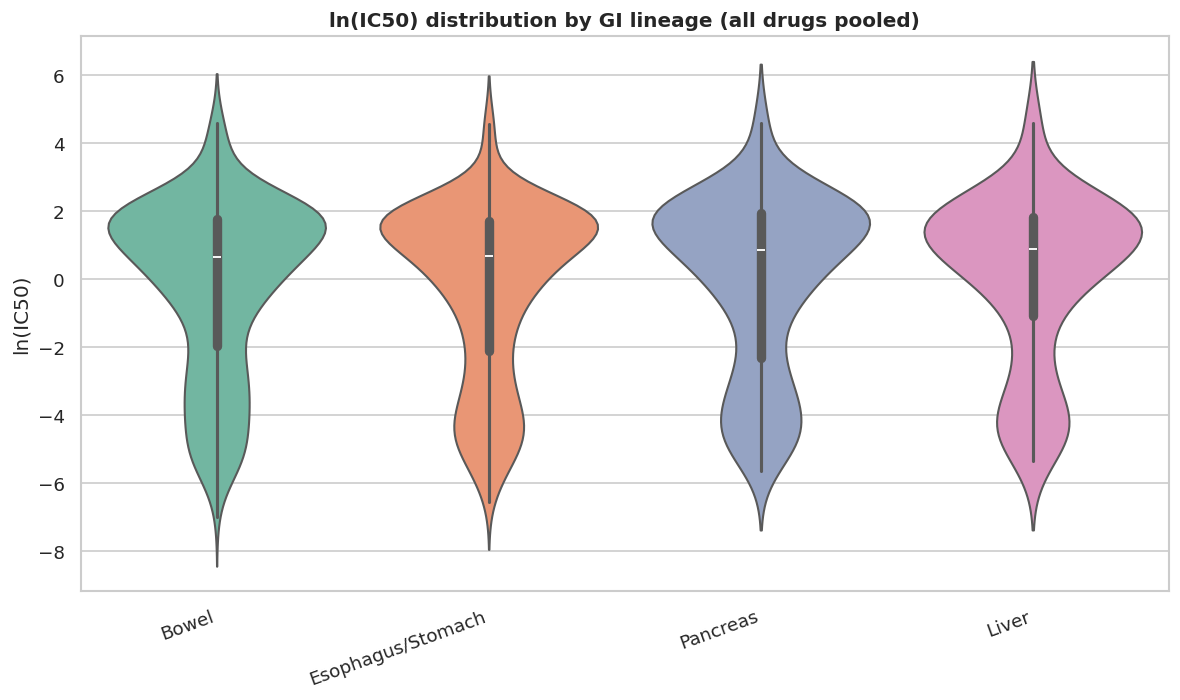

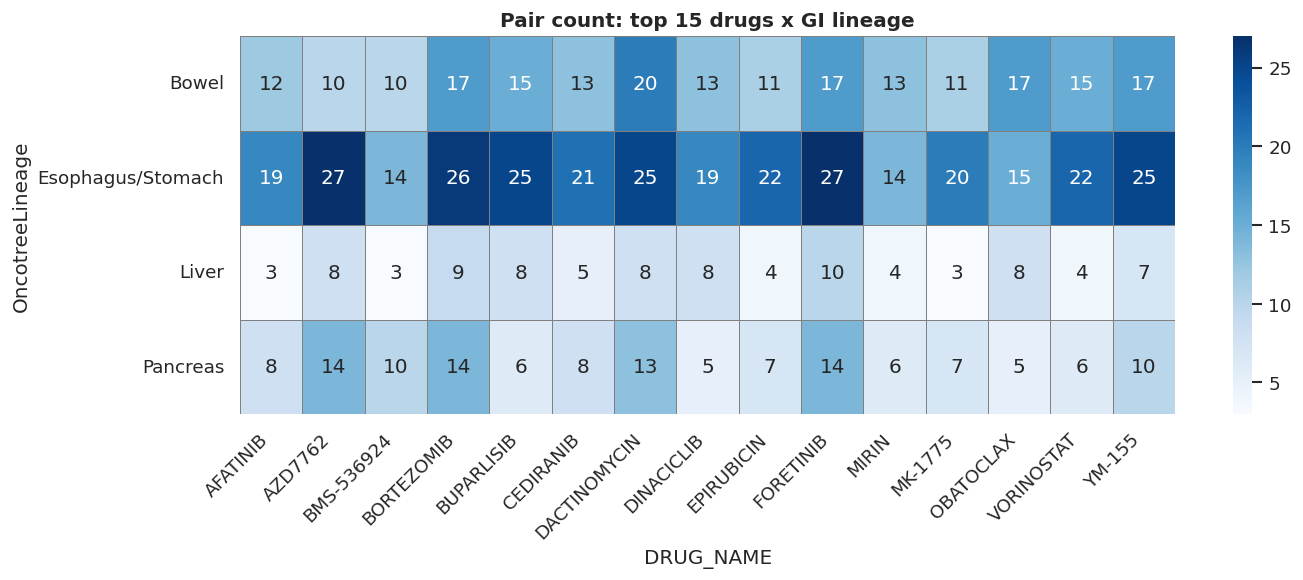

In [12]:
section('Figure: IC50 distribution by lineage')

fig, ax = plt.subplots(figsize=(10, 6))
lineage_order = ic50.groupby('OncotreeLineage')['ic50_value'].median().sort_values().index
sns.violinplot(data=ic50, x='OncotreeLineage', y='ic50_value', order=lineage_order,
                palette='Set2', ax=ax)
ax.set_title('ln(IC50) distribution by GI lineage (all drugs pooled)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('ln(IC50)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('gi_stage2_ic50_by_lineage.png', dpi=150, bbox_inches='tight')
plt.show()

top_drugs_by_pairs = ic50['DRUG_NAME'].value_counts().head(15).index
cov = ic50[ic50['DRUG_NAME'].isin(top_drugs_by_pairs)].pivot_table(
    index='OncotreeLineage', columns='DRUG_NAME', values='ic50_value', aggfunc='count', fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cov, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5, linecolor='gray')
ax.set_title('Pair count: top 15 drugs x GI lineage', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('gi_stage2_drug_lineage_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
section('Scale omics data (fit fresh on GI cell-cold TRAIN cell lines)')

print(f'Fitting scalers on {len(cl_cell_train)} strictly-training GI cell lines '
      f'({len(cl_cell_train)/len(common_final)*100:.1f}% of {len(common_final)}).')

def scale_modality(df, train_ids, scaler_type, tag):
    train_mask = df.index.isin(set(train_ids))
    X_train = df.loc[train_mask].values
    if scaler_type == 'standard':
        sc = StandardScaler(); sc.fit(X_train)
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler(); sc.fit(X_train)
    else:
        sc = None
    scaled_vals = sc.transform(df.values) if sc is not None else df.values.copy()
    out = pd.DataFrame(scaled_vals.astype(np.float32), index=df.index, columns=df.columns)
    train_vals = out.loc[train_mask].values
    print(f'  [{tag:<4}] {scaler_type:<10} | train mean={train_vals.mean():+.4f} std={train_vals.std():.4f}')
    return out, sc

mrna_scaled, sc_mrna = scale_modality(mrna_df, cl_cell_train, 'standard', 'mRNA')
cnv_scaled,  sc_cnv  = scale_modality(cnv_df,  cl_cell_train, 'maxabs',   'CNV')
mut_scaled,  _       = scale_modality(mut_df,  cl_cell_train, 'none',     'Mut')
meth_scaled, _       = scale_modality(meth_df, cl_cell_train, 'none',     'Meth')

del mrna_df, cnv_df, mut_df, meth_df
gc.collect()
print('\nScaling complete.')



  Scale omics data (fit fresh on GI cell-cold TRAIN cell lines)
Fitting scalers on 53 strictly-training GI cell lines (67.1% of 79).
  [mRNA] standard   | train mean=-0.0000 std=0.9711
  [CNV ] maxabs     | train mean=-0.4828 std=0.2809
  [Mut ] none       | train mean=+0.0372 std=0.1893
  [Meth] none       | train mean=+0.4032 std=0.2828

Scaling complete.


In [14]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 46.6 MB/s eta 0:00:00


In [15]:
section('Save all outputs')
import joblib
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

OUT = CFG['OUT_DIR']

mrna_scaled.to_parquet(f'{OUT}ccle_mrna_gi_scaled.parquet')
cnv_scaled.to_parquet( f'{OUT}ccle_cnv_gi_scaled.parquet')
mut_scaled.to_parquet( f'{OUT}ccle_mut_gi_scaled.parquet')
meth_scaled.to_parquet(f'{OUT}ccle_meth_gi_scaled.parquet')
print('Saved: ccle_{mrna,cnv,mut,meth}_gi_scaled.parquet')

split_files = {
    'split_gi_warm_tr': ic50_warm_tr, 'split_gi_warm_vl': ic50_warm_vl, 'split_gi_warm_te': ic50_warm_te,
    'split_gi_cc_tr':   ic50_cc_tr,   'split_gi_cc_vl':   ic50_cc_vl,   'split_gi_cc_te':   ic50_cc_te,
}
for fname, df_split in split_files.items():
    df_split.to_parquet(f'{OUT}{fname}.parquet', index=False)
print('Saved: 6 IC50 split parquets')

joblib.dump(sc_mrna, f'{OUT}scaler_mrna_gi.pkl')
joblib.dump(sc_cnv,  f'{OUT}scaler_cnv_gi.pkl')
print('Saved: scaler_mrna_gi.pkl, scaler_cnv_gi.pkl (fit fresh on GI CCLE data)')

# -- Morgan fingerprints computed fresh from SMILES -- the standard method now,
# not a bolted-on fix -- since the precomputed fingerprint files were found missing.
with open(f"{CFG['GDSC2_BASE']}/drug_smiles.json") as f:
    smiles_map = json.load(f)

FP_RADIUS, FP_NBITS = 2, 1024
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)

gi_drugs = sorted(ic50['DRUG_NAME'].unique())
print(f'\nComputing ECFP4 fingerprints for {len(gi_drugs)} GI drugs...')
fps_dict, failed = {}, []
for drug in gi_drugs:
    smiles = smiles_map.get(drug)
    if not smiles:
        failed.append(drug); continue
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            failed.append(drug); continue
        fps_dict[drug] = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
    except Exception:
        failed.append(drug)

print(f'  Computed: {len(fps_dict)}/{len(gi_drugs)} drugs')
if failed:
    print(f'  Failed: {failed}')

gi_drugs_with_fp = sorted(fps_dict.keys())
gi_fp_matrix = np.array([fps_dict[d] for d in gi_drugs_with_fp], dtype=np.float32)
np.save(f'{OUT}gi_drug_morgan_fps.npy', gi_fp_matrix)
with open(f'{OUT}gi_drug_morgan_fp_order.json', 'w') as f:
    json.dump(gi_drugs_with_fp, f, indent=2)

gi_drug2idx = {d: i for i, d in enumerate(gi_drugs_with_fp)}
with open(f'{OUT}gi_drug2idx.json', 'w') as f:
    json.dump(gi_drug2idx, f)
pd.Series(gi_drugs_with_fp).to_csv(f'{OUT}gi_valid_drug_names.csv', index=False, header=False)
print(f'Saved: gi_drug_morgan_fps.npy {gi_fp_matrix.shape}, gi_drug2idx.json, gi_valid_drug_names.csv')

print('\n' + '=' * 65)
print('  FINAL GI STAGE 2 DATASET SUMMARY')
print('=' * 65)
print(f'  Cell lines:          {len(common_final)}')
print(f'  Drugs (with FP):     {len(gi_drugs_with_fp)}')
print(f'  mRNA/CNV/Mut/Meth:   {mrna_scaled.shape[1]}/{cnv_scaled.shape[1]}/'
      f'{mut_scaled.shape[1]}/{meth_scaled.shape[1]} genes')
print(f'  WARM-START:      Train {len(ic50_warm_tr):>5,} | Val {len(ic50_warm_vl):>4,} | Test {len(ic50_warm_te):>4,}')
print(f'  CELL-COLD-START: Train {len(ic50_cc_tr):>5,} | Val {len(ic50_cc_vl):>4,} | Test {len(ic50_cc_te):>4,}')
print(f'  Single-modality preview: {modality_regression_results}')
print('=' * 65)
print('GI Stage 2 data processing complete.')



  Save all outputs
Saved: ccle_{mrna,cnv,mut,meth}_gi_scaled.parquet
Saved: 6 IC50 split parquets
Saved: scaler_mrna_gi.pkl, scaler_cnv_gi.pkl (fit fresh on GI CCLE data)

Computing ECFP4 fingerprints for 71 GI drugs...
  Computed: 71/71 drugs
Saved: gi_drug_morgan_fps.npy (71, 1024), gi_drug2idx.json, gi_valid_drug_names.csv

  FINAL GI STAGE 2 DATASET SUMMARY
  Cell lines:          79
  Drugs (with FP):     71
  mRNA/CNV/Mut/Meth:   2000/300/300/2000 genes
  WARM-START:      Train 1,263 | Val  158 | Test  158
  CELL-COLD-START: Train 1,111 | Val  170 | Test  298
  Single-modality preview: {'mRNA': np.float64(0.4961796959396036), 'CNV': np.float64(-0.051532721714857725), 'Mutation': np.float64(0.1049208375582387), 'Methylation': np.float64(0.33105975991648184)}
GI Stage 2 data processing complete.
